<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `HippocampalPlaceCellExample.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now reproduces the dataset-backed place-cell model-comparison and field-visualization workflow with the same normalized 10-term Zernike basis used by MATLAB; exact AIC/BIC values and surface styling still vary modestly because the Python GLM solver and plotting backend are not byte-identical to MATLAB.


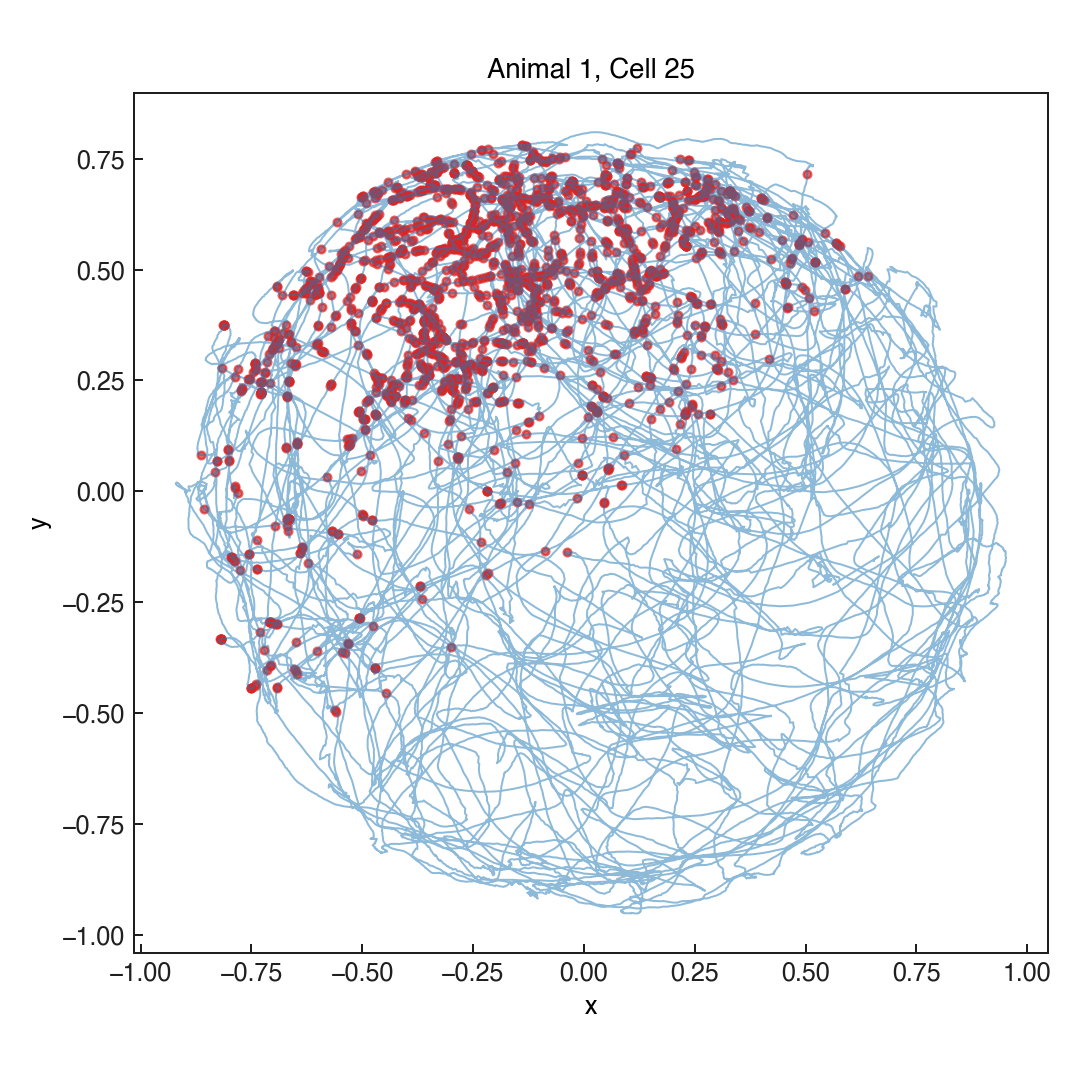

In [1]:
# nSTAT-python notebook example: HippocampalPlaceCellExample
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_data import notebook_example_data_dir
from nstat.notebook_figures import FigureTracker
from nstat.paper_examples_full import run_experiment4

np.random.seed(0)
DATA_DIR = notebook_example_data_dir(allow_synthetic=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='HippocampalPlaceCellExample', output_root=OUTPUT_ROOT, expected_count=12)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _interp_spike_positions(time_s, x_pos, y_pos, spike_times):
    spike_times = np.asarray(spike_times, dtype=float)
    return (
        np.interp(spike_times, np.asarray(time_s, dtype=float), np.asarray(x_pos, dtype=float)),
        np.interp(spike_times, np.asarray(time_s, dtype=float), np.asarray(y_pos, dtype=float)),
    )


def _plot_field_grid(fig, animal_key, field_key, title):
    animal = payload[animal_key]
    grid_x = np.asarray(animal["grid_x"], dtype=float)
    grid_y = np.asarray(animal["grid_y"], dtype=float)
    fields = np.asarray(animal[field_key], dtype=float)
    labels = np.asarray(animal["selected_indices"], dtype=int) + 1
    # Share the color scale across the 4 panels so a single colorbar is
    # physically meaningful for every cell.
    vmin = float(np.nanmin(fields))
    vmax = float(np.nanmax(fields))
    axs = fig.subplots(2, 2, squeeze=False)
    for ax, field, label in zip(axs.ravel(), fields, labels, strict=False):
        image = ax.imshow(
            field,
            origin="lower",
            extent=[float(grid_x.min()), float(grid_x.max()), float(grid_y.min()), float(grid_y.max())],
            aspect="equal",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"Cell {label}")
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    # Reserve a strip on the right of the figure for the colorbar and
    # place a dedicated cbar axes there. The FigureTracker._save_active()
    # call invokes fig.tight_layout() after we return, which would reset
    # the layout and push the colorbar back into the heatmaps -- so we
    # neutralise that call for this specific figure.
    fig.subplots_adjust(left=0.05, right=0.85, bottom=0.06, top=0.92, wspace=0.08, hspace=0.18)
    cbar_ax = fig.add_axes([0.88, 0.06, 0.025, 0.86])
    fig.colorbar(image, cax=cbar_ax)
    fig.tight_layout = lambda *args, **kwargs: None

In [2]:
# SECTION 0: HIPPOCAMPAL PLACE CELL - RECEPTIVE FIELD ESTIMATION
# This notebook mirrors the MATLAB place-cell helpfile using the dataset-backed Python workflow.
plt.close("all")
summary, payload = run_experiment4(DATA_DIR, return_payload=True)
print(
    {
        "num_cells_fit": int(summary["num_cells_fit"]),
        "mean_delta_aic": round(float(summary["mean_delta_aic_gaussian_minus_zernike"]), 3),
        "mean_delta_bic": round(float(summary["mean_delta_bic_gaussian_minus_zernike"]), 3),
    }
)


{'num_cells_fit': 8, 'mean_delta_aic': 89.651, 'mean_delta_bic': 55.016}


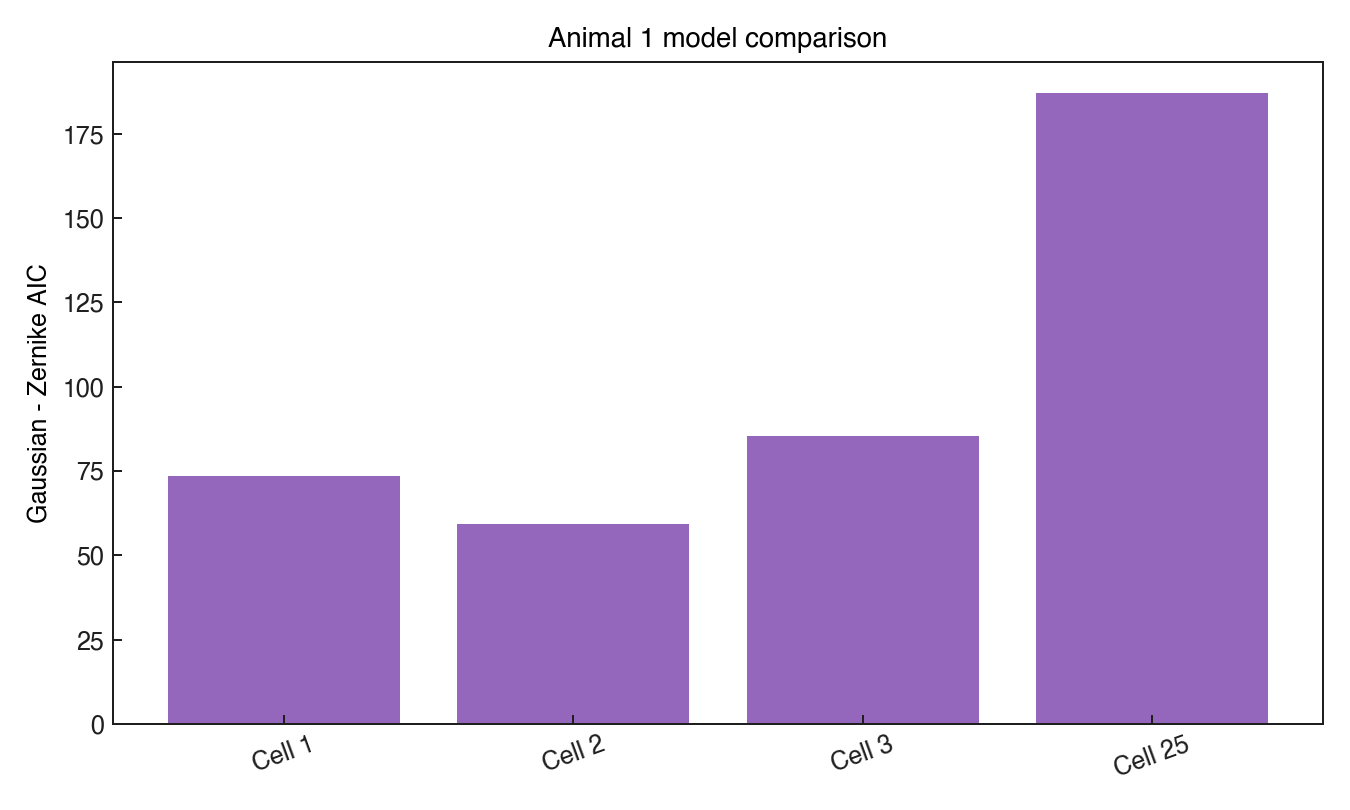

In [3]:
# SECTION 1: Example Data
mesh = payload["mesh"]
spike_x, spike_y = _interp_spike_positions(mesh["time_s"], mesh["x_pos"], mesh["y_pos"], mesh["spike_times"])
fig = _prepare_figure("figure(1)", figsize=(6.0, 6.0))
ax = fig.subplots(1, 1)
ax.plot(mesh["x_pos"], mesh["y_pos"], color="tab:blue", linewidth=0.8, alpha=0.5)
ax.scatter(spike_x, spike_y, s=9, color="tab:red", alpha=0.7)
ax.set_title(f"Animal 1, Cell {int(mesh['cell_index']) + 1}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")


Text(0.5, 1.0, 'Animal 1 model comparison')

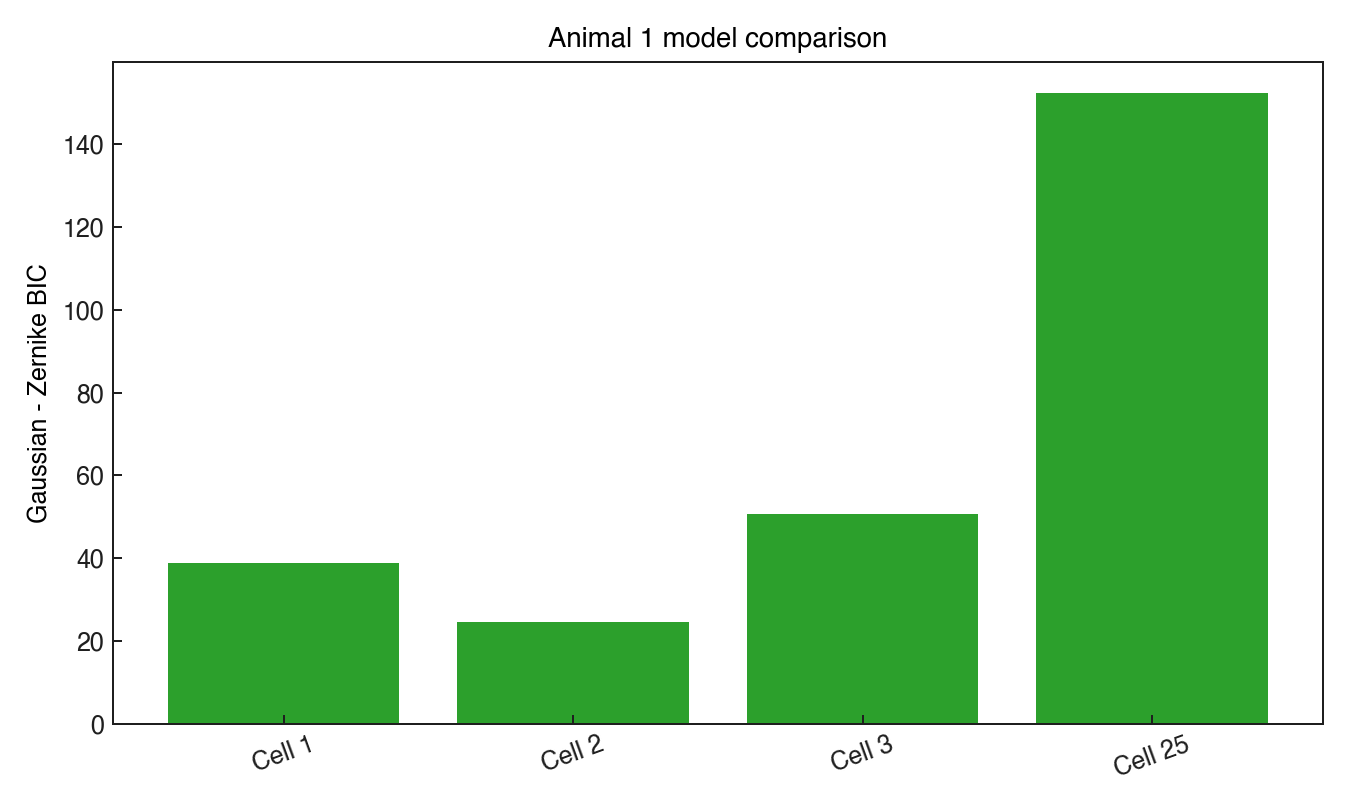

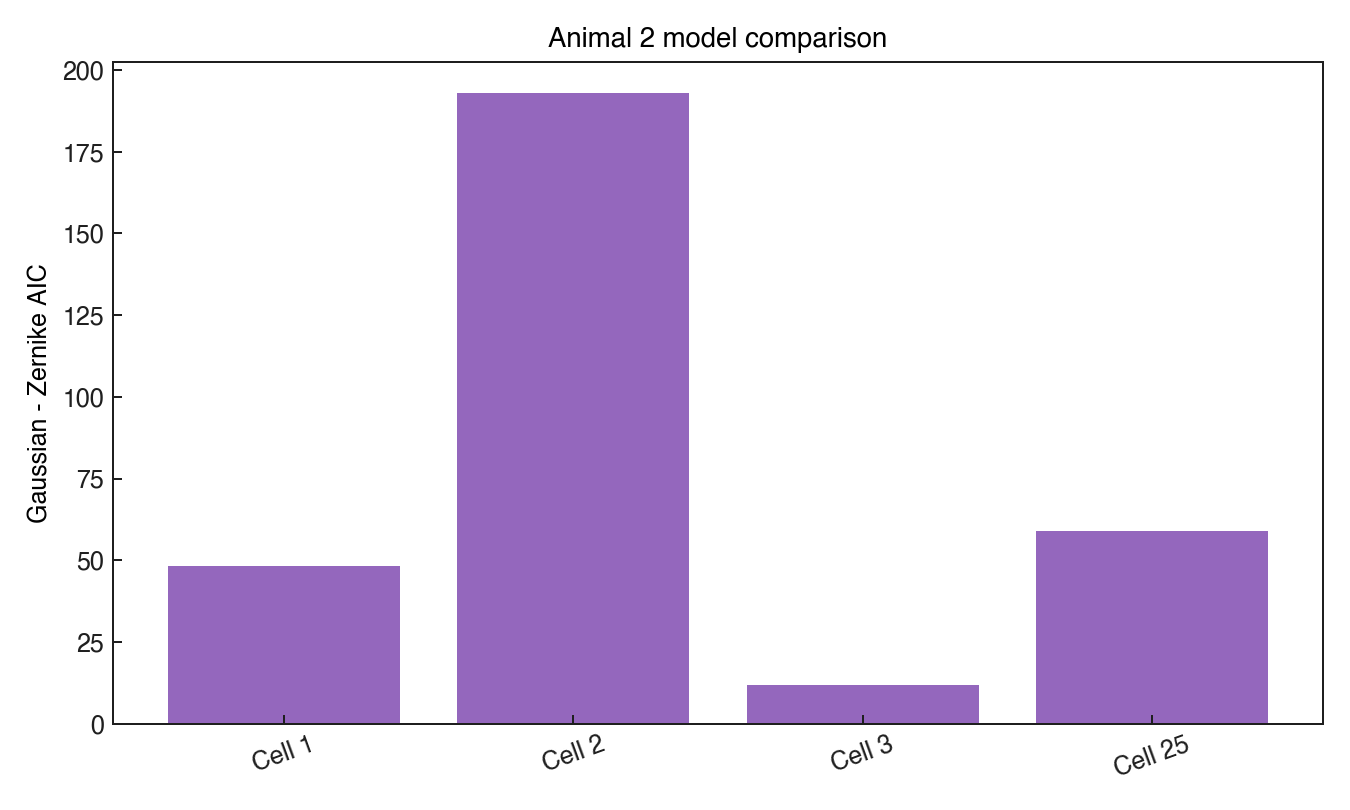

In [4]:
# SECTION 2: Analyze All Cells
fig = _prepare_figure("Summary.plotSummary", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
animal1 = payload["animal1"]
labels = [f"Cell {int(idx) + 1}" for idx in np.asarray(animal1["selected_indices"], dtype=int)]
ax.bar(np.arange(len(labels)), animal1["delta_aic"], color="tab:purple")
ax.axhline(0.0, color="0.2", linewidth=1.0)
ax.set_xticks(np.arange(len(labels)), labels, rotation=20)
ax.set_ylabel("Gaussian - Zernike AIC")
ax.set_title("Animal 1 model comparison")

fig = _prepare_figure("Summary.plotSummary", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
ax.bar(np.arange(len(labels)), animal1["delta_bic"], color="tab:green")
ax.axhline(0.0, color="0.2", linewidth=1.0)
ax.set_xticks(np.arange(len(labels)), labels, rotation=20)
ax.set_ylabel("Gaussian - Zernike BIC")
ax.set_title("Animal 1 model comparison")


Text(0.5, 1.0, 'Animal 2 model comparison')

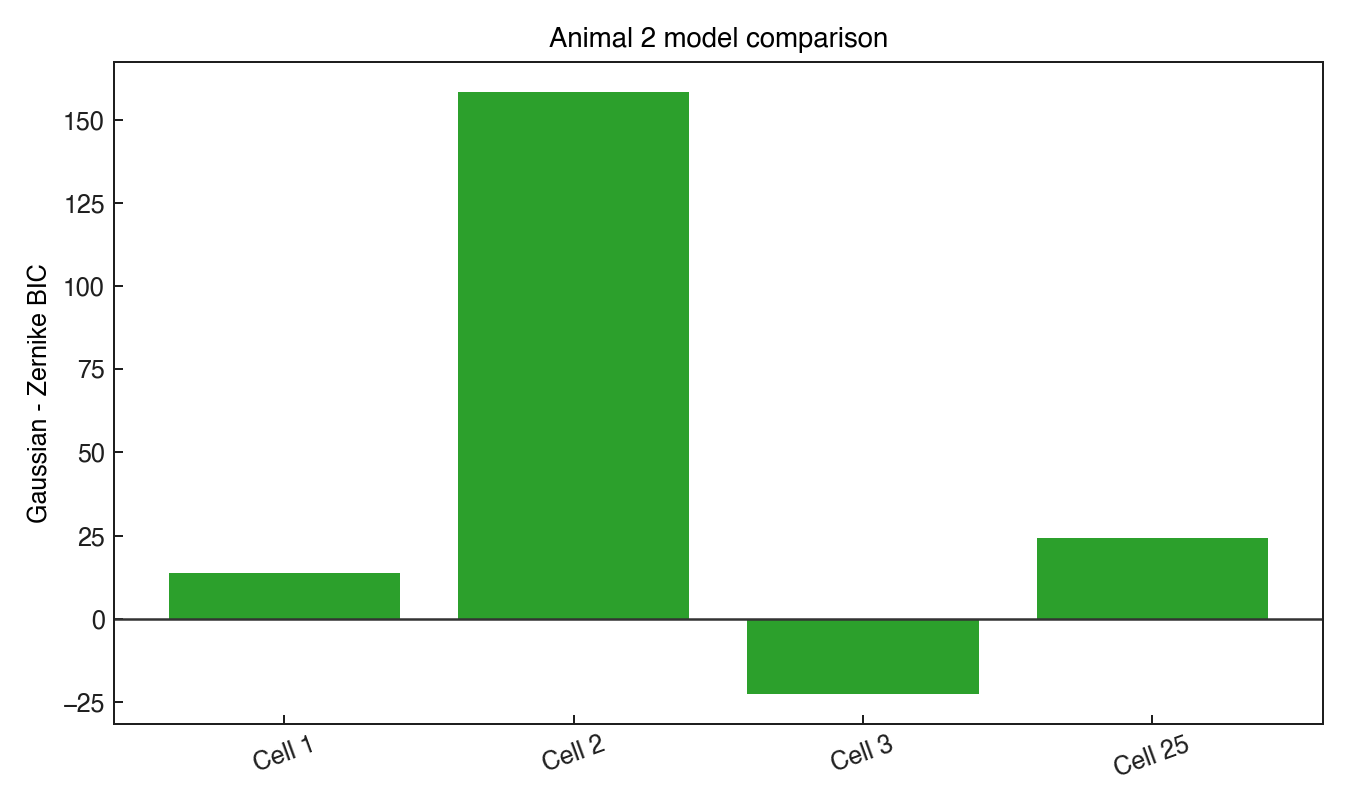

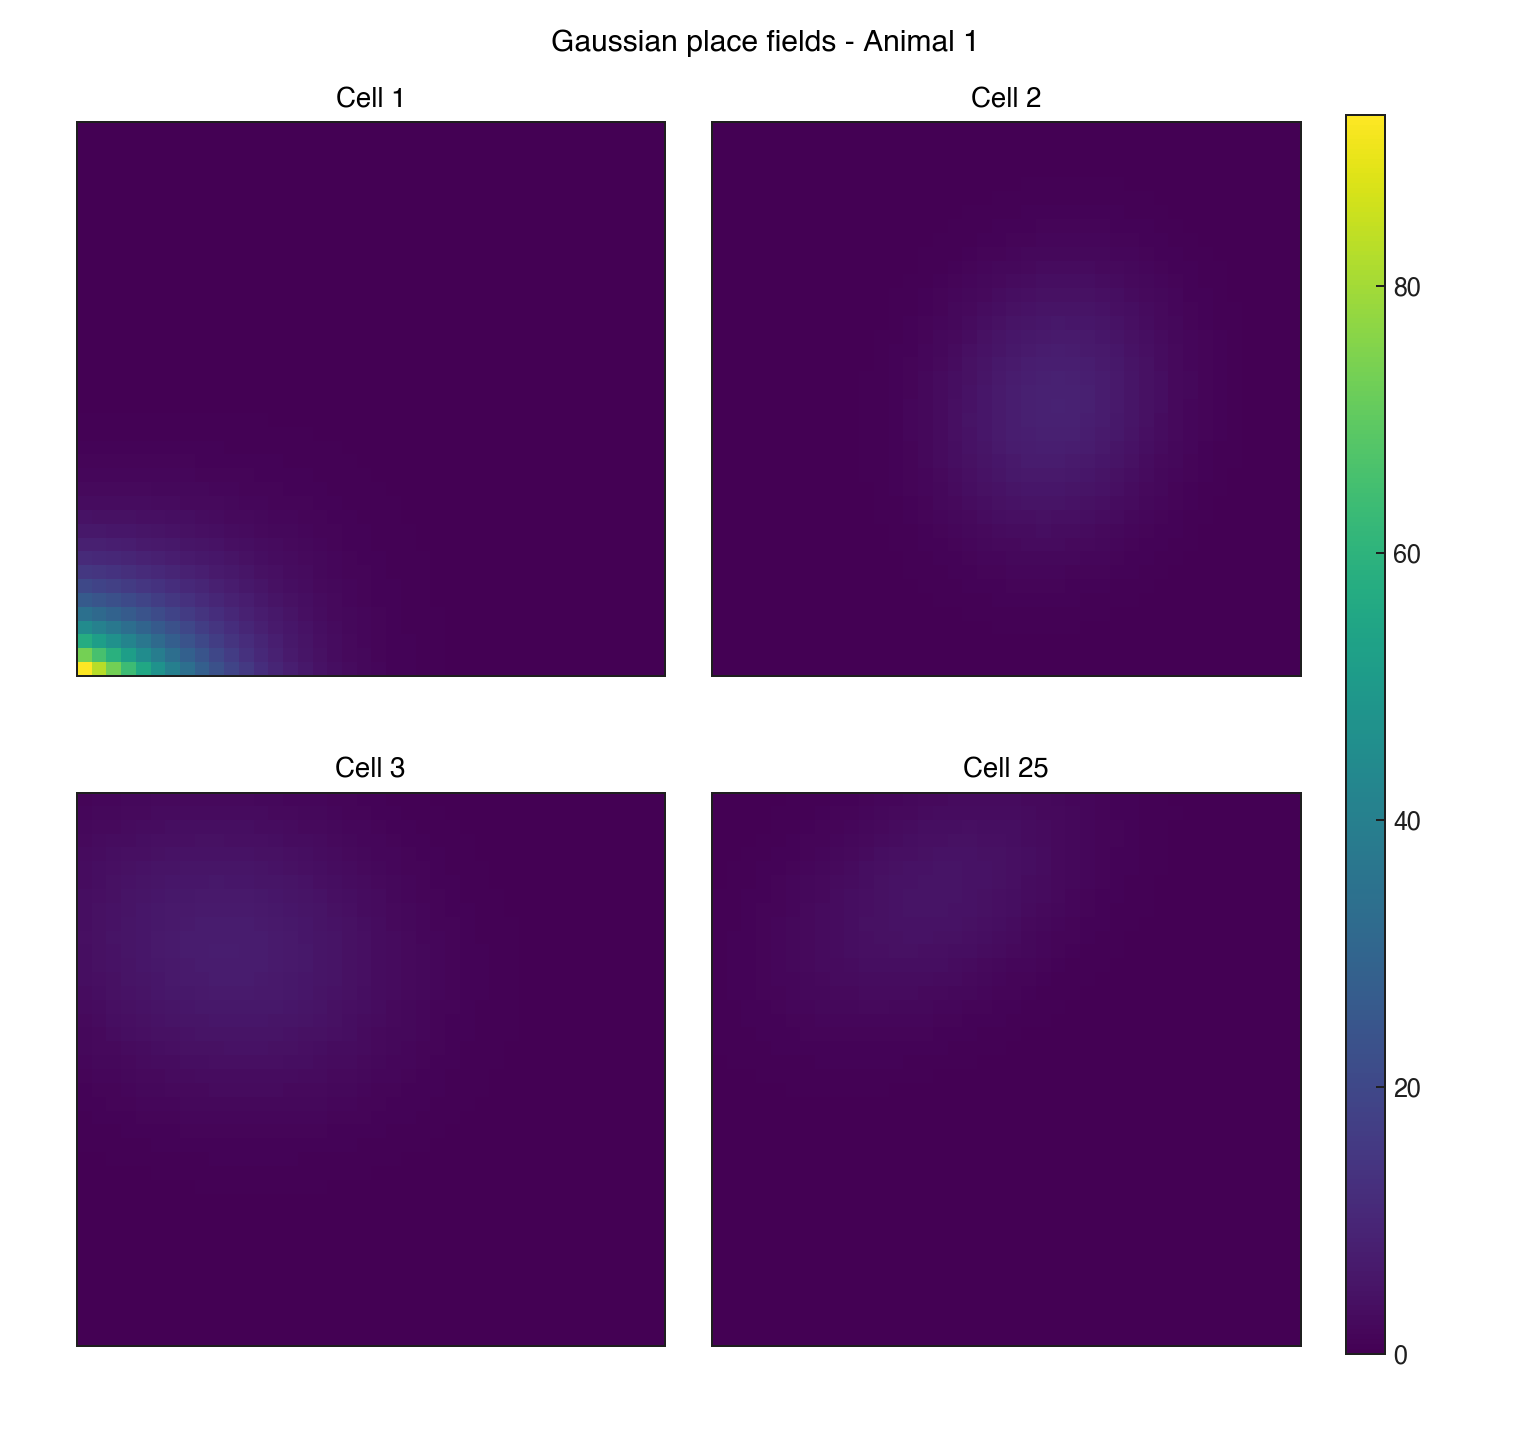

In [5]:
# SECTION 3: View Summary Statistics
fig = _prepare_figure("Summary.plotSummary", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
animal2 = payload["animal2"]
labels = [f"Cell {int(idx) + 1}" for idx in np.asarray(animal2["selected_indices"], dtype=int)]
ax.bar(np.arange(len(labels)), animal2["delta_aic"], color="tab:purple")
ax.axhline(0.0, color="0.2", linewidth=1.0)
ax.set_xticks(np.arange(len(labels)), labels, rotation=20)
ax.set_ylabel("Gaussian - Zernike AIC")
ax.set_title("Animal 2 model comparison")

fig = _prepare_figure("Summary.plotSummary", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
ax.bar(np.arange(len(labels)), animal2["delta_bic"], color="tab:green")
ax.axhline(0.0, color="0.2", linewidth=1.0)
ax.set_xticks(np.arange(len(labels)), labels, rotation=20)
ax.set_ylabel("Gaussian - Zernike BIC")
ax.set_title("Animal 2 model comparison")


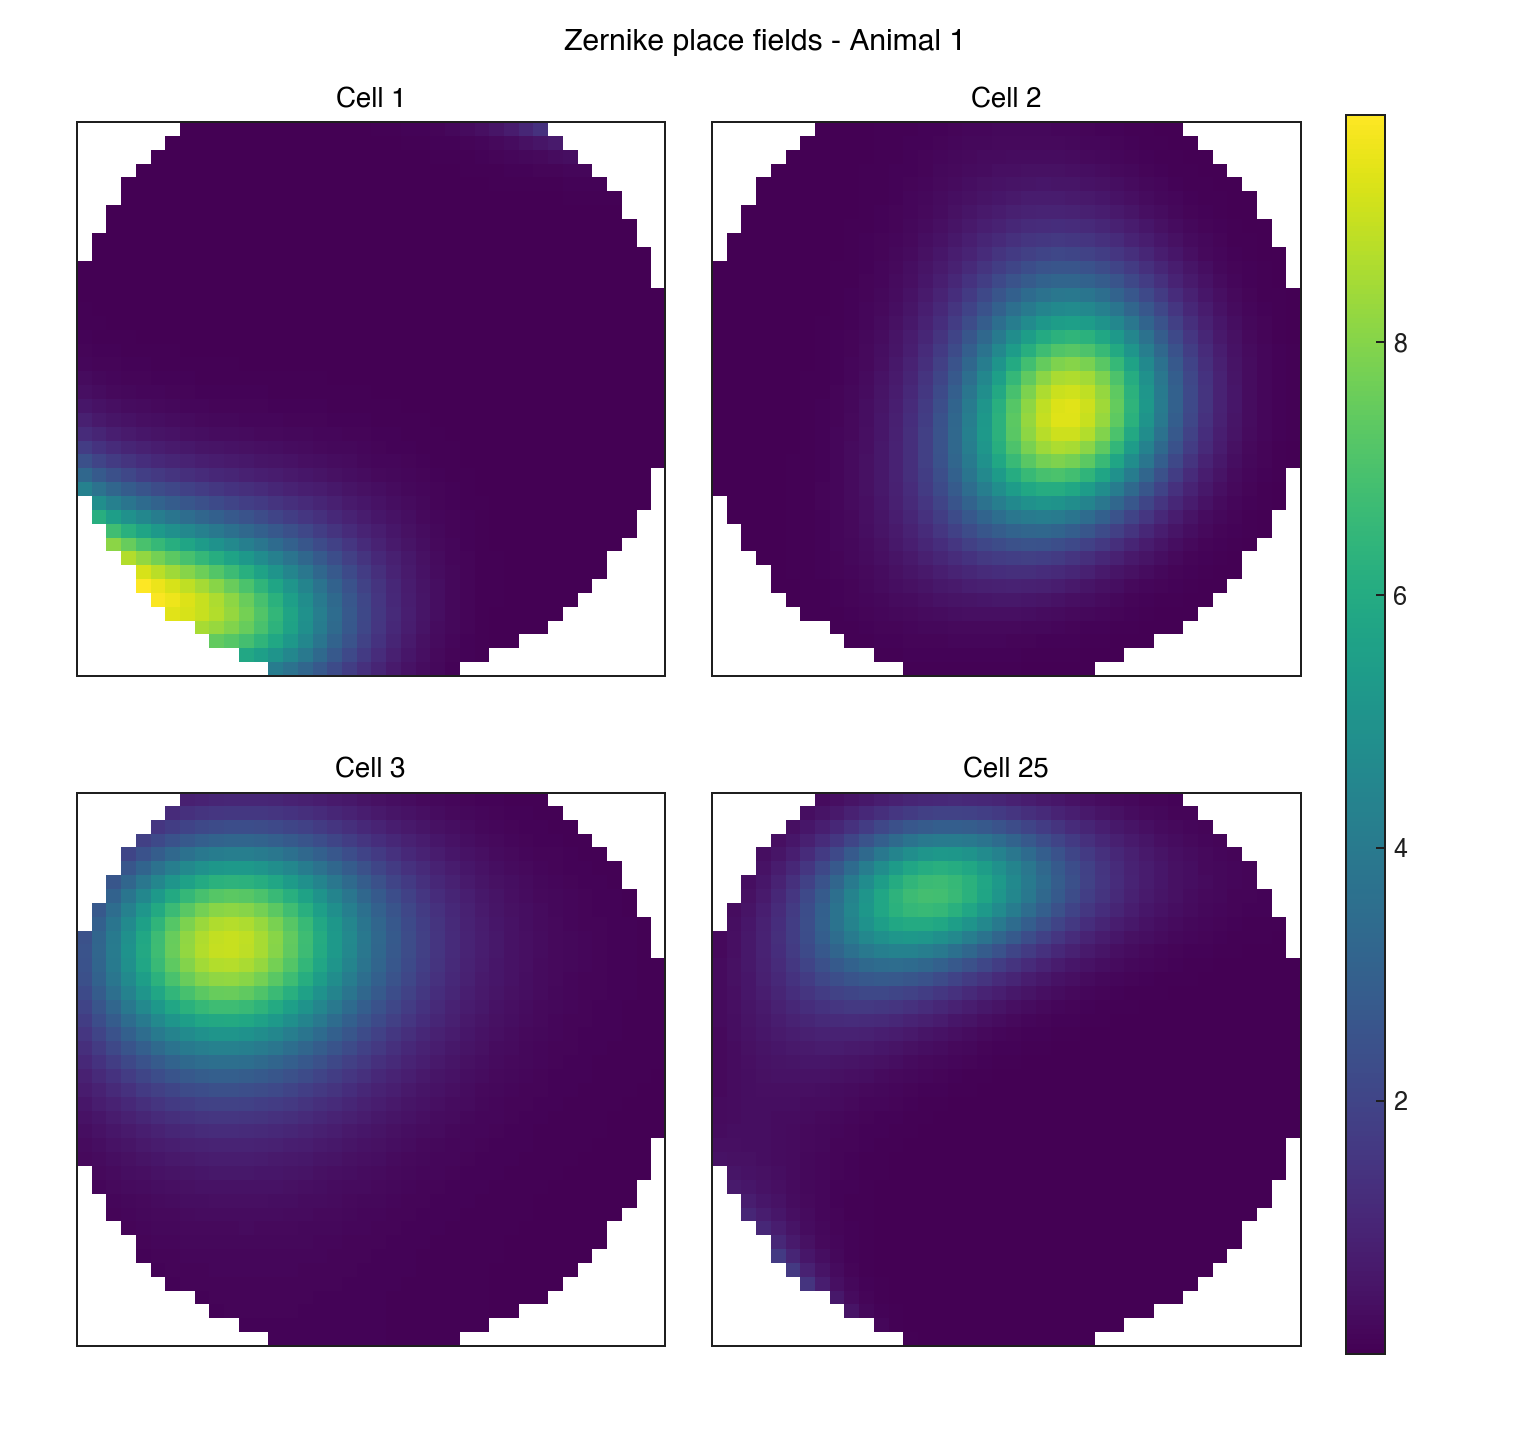

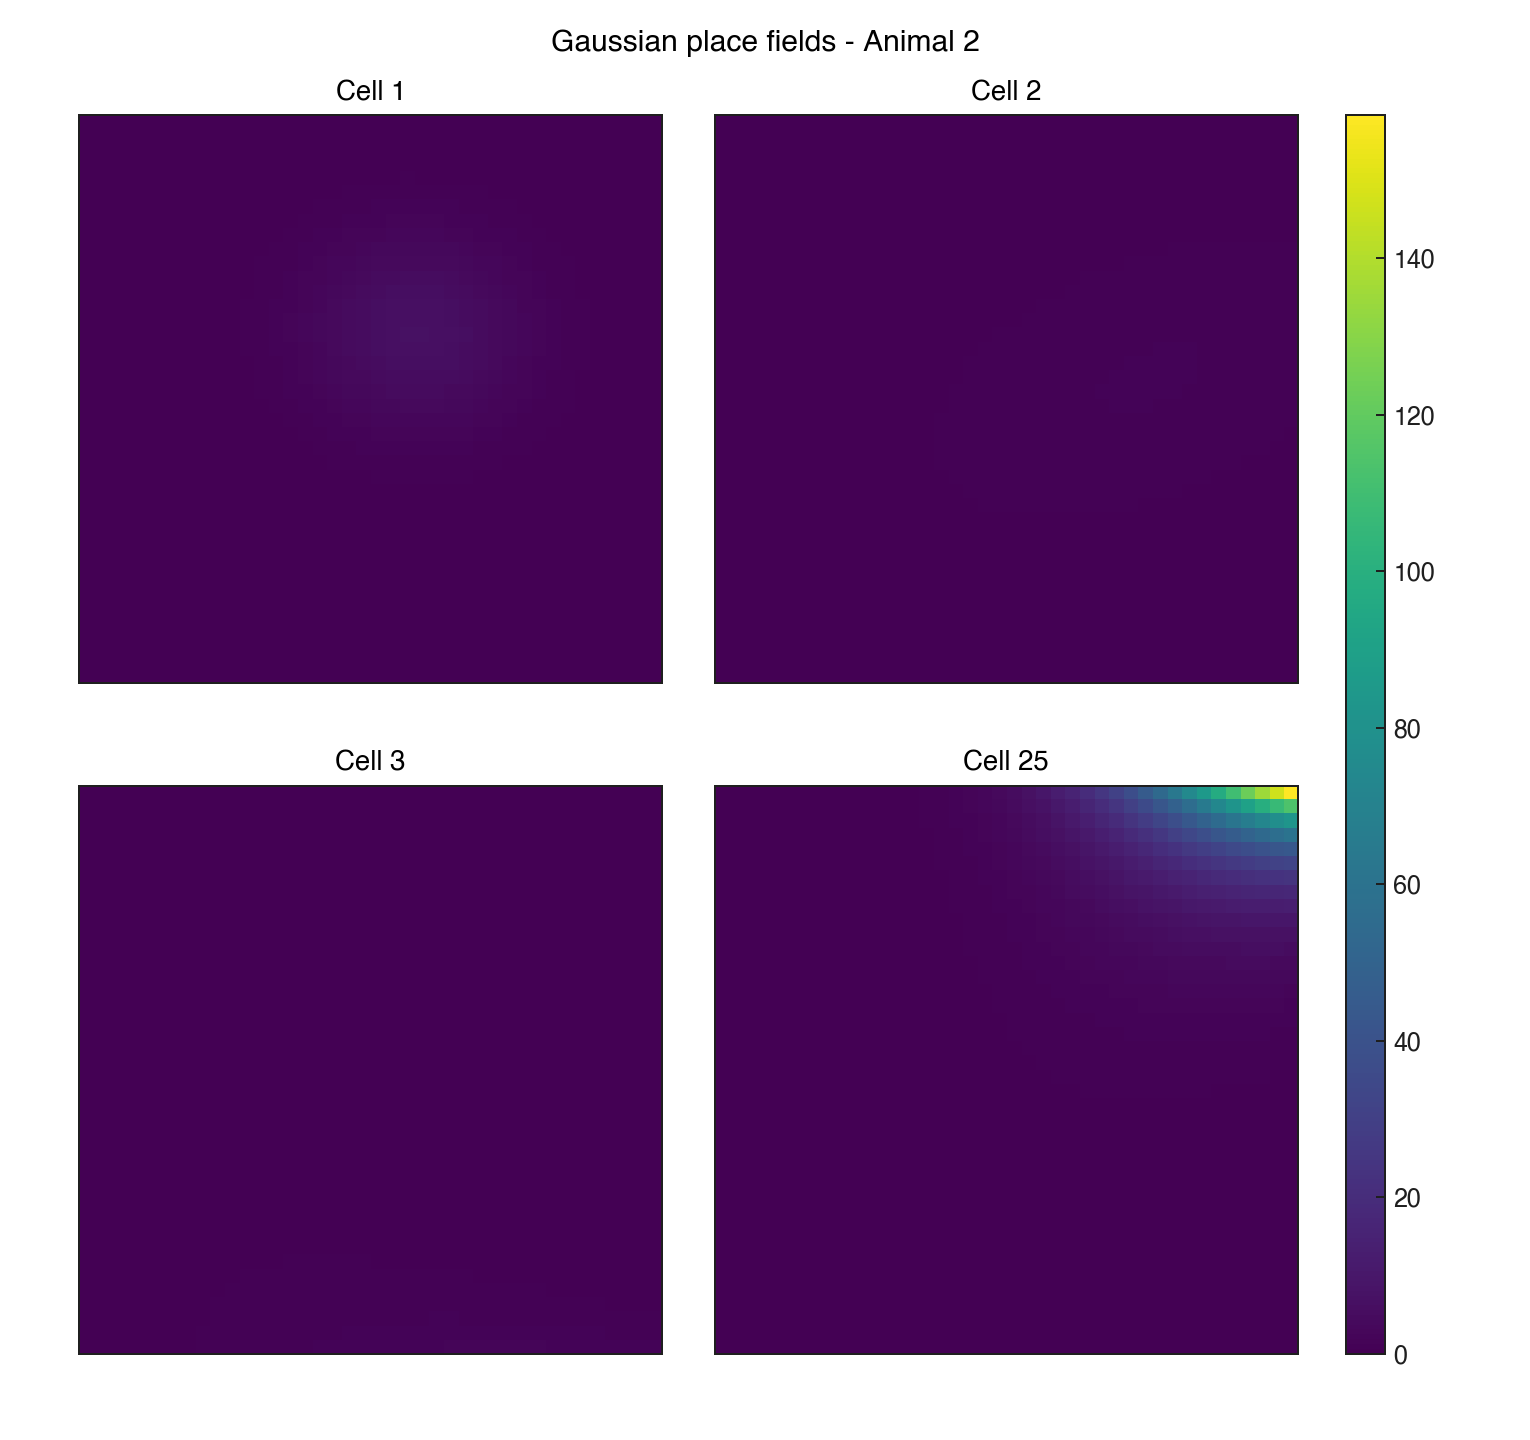

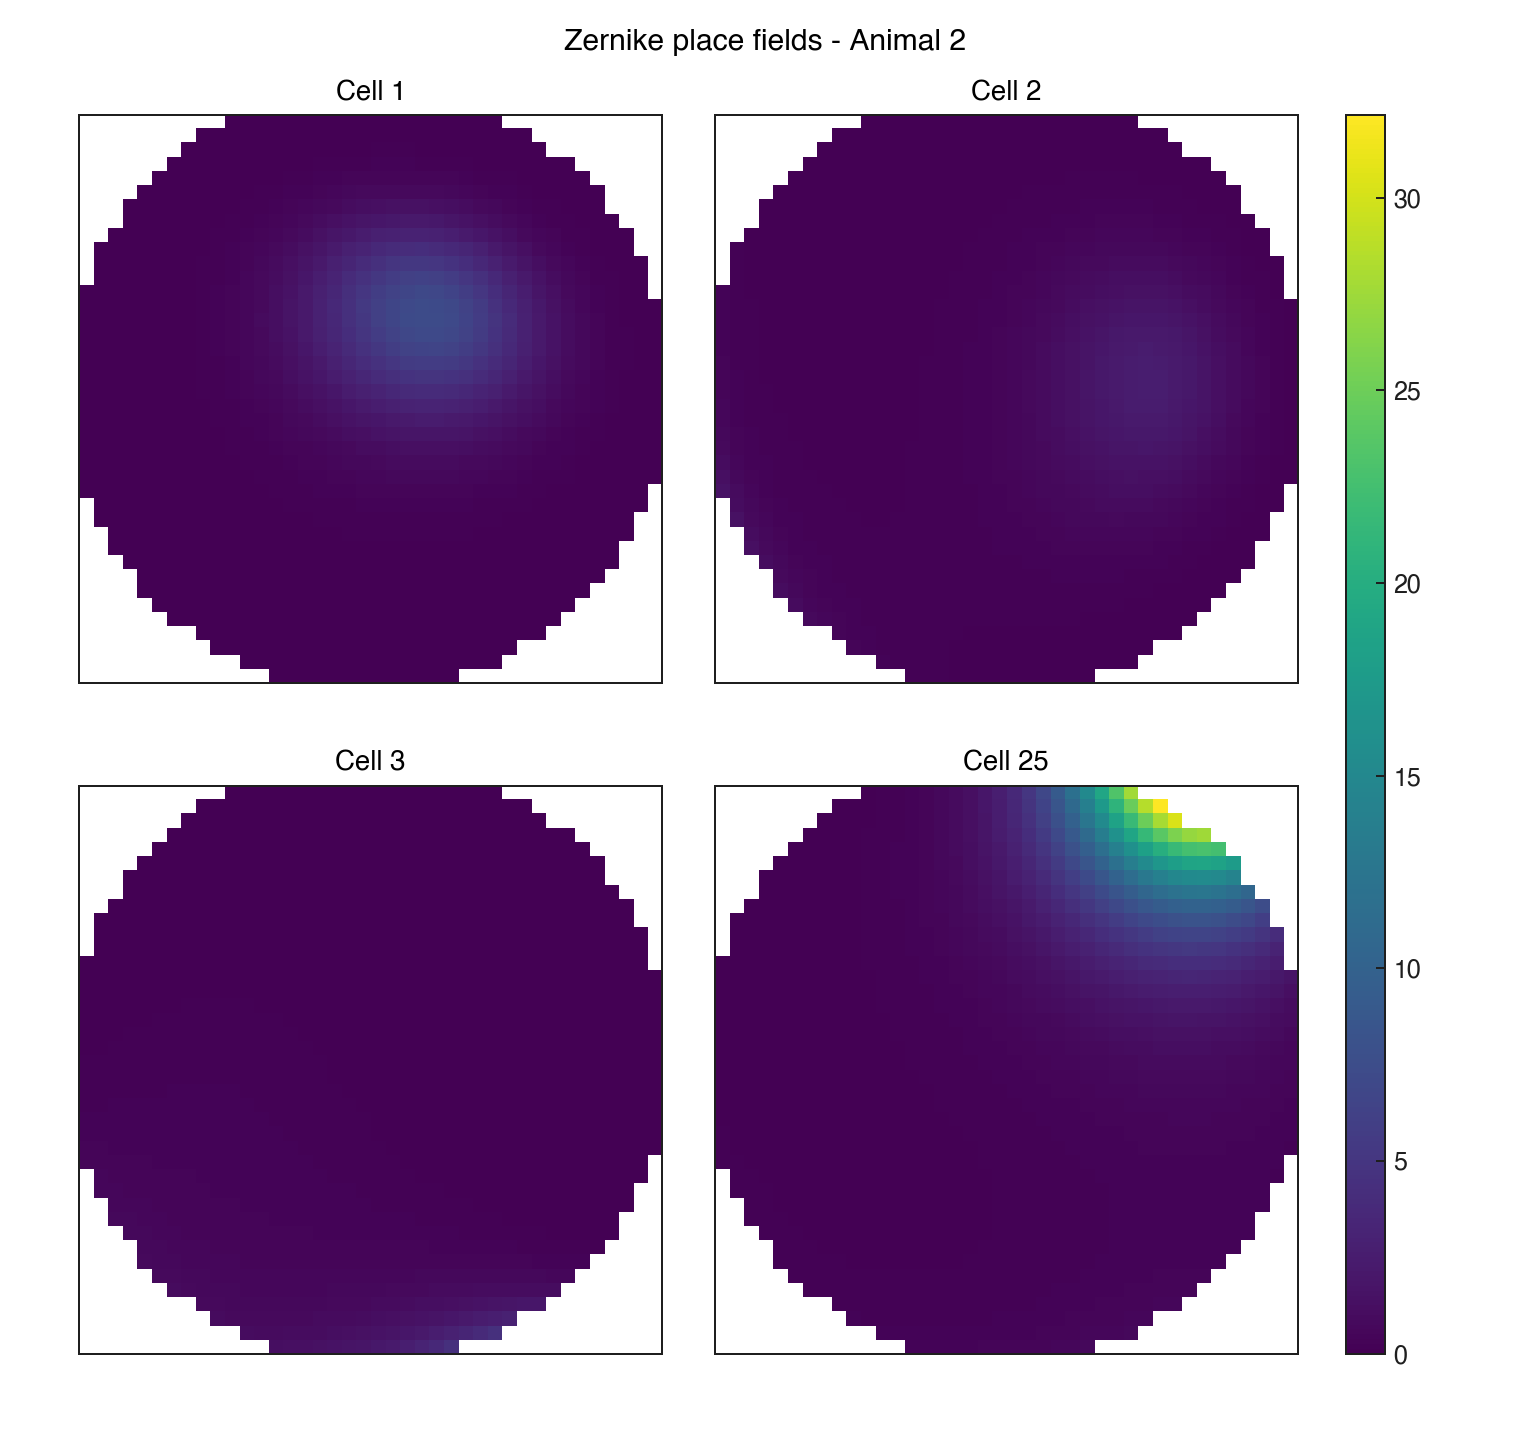

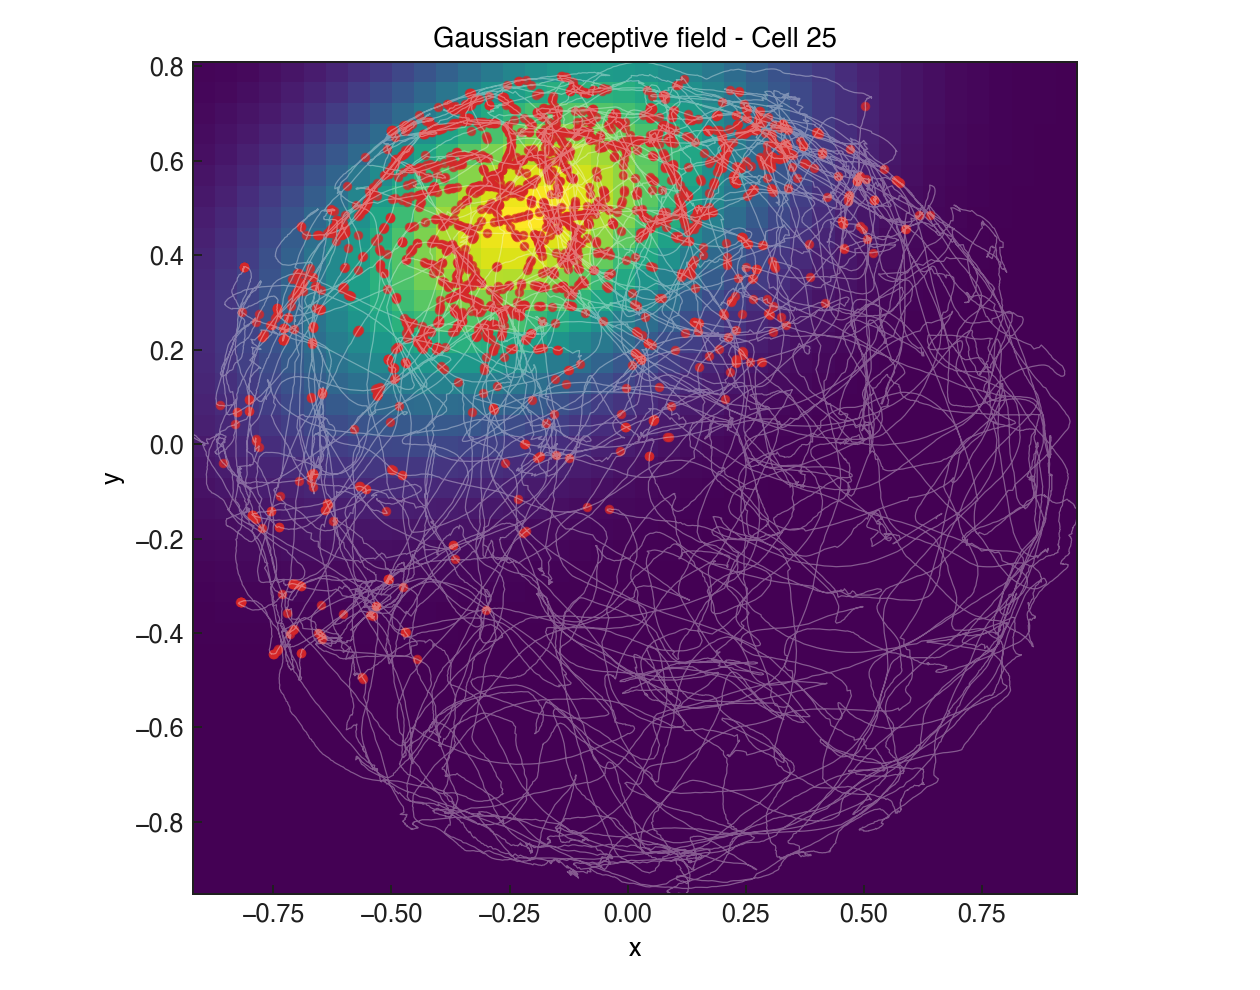

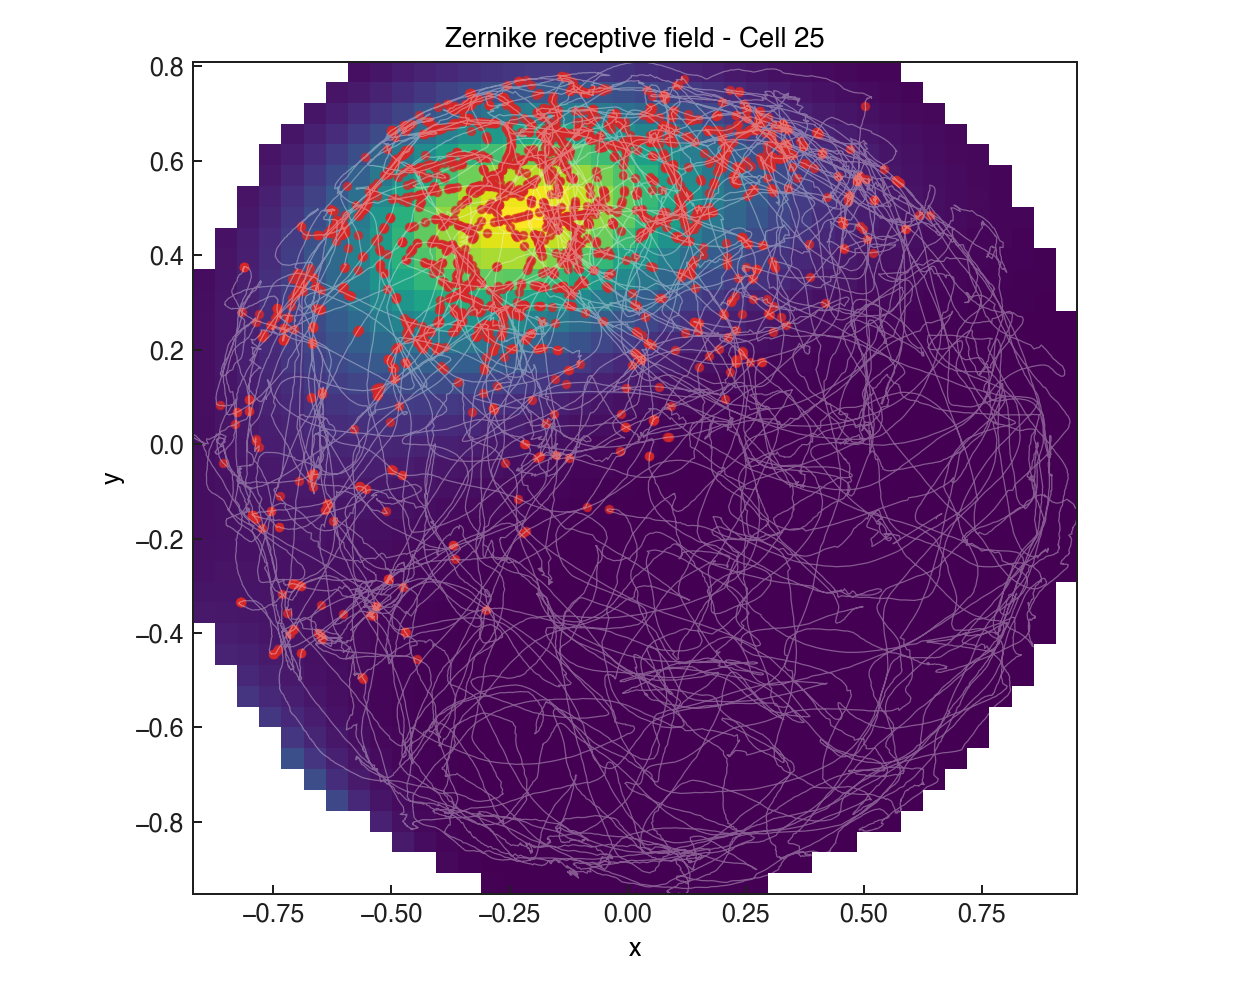

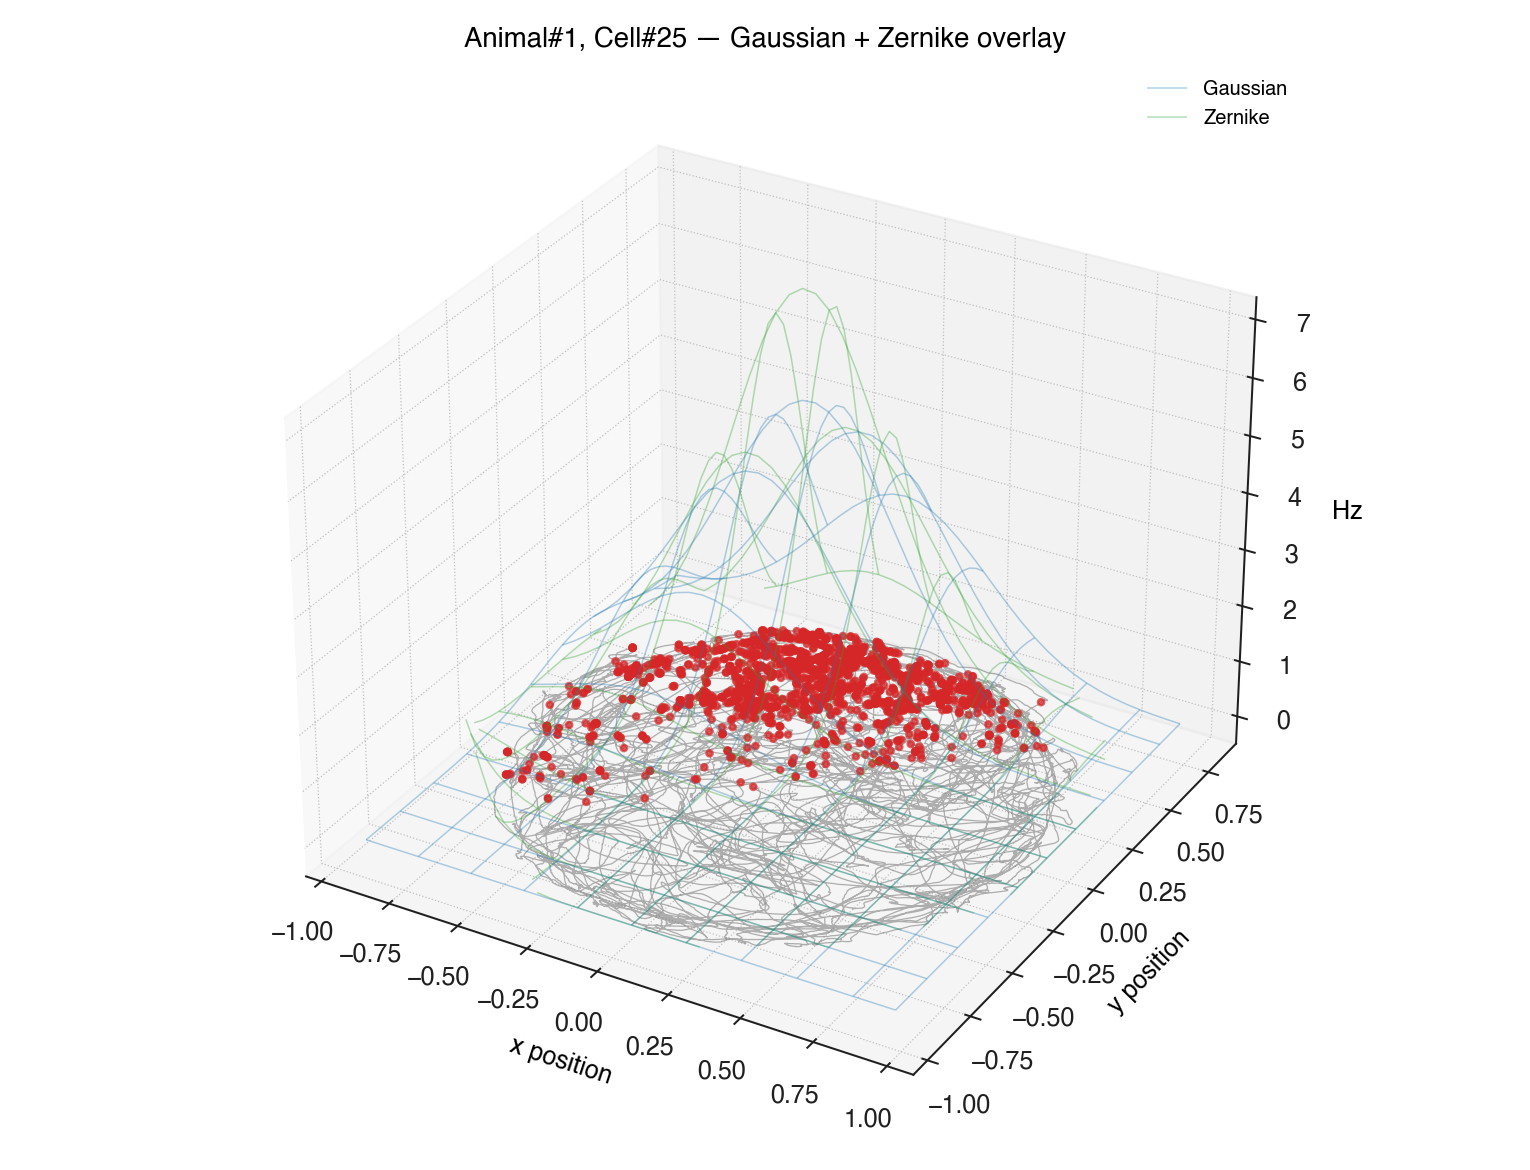

In [6]:
# SECTION 4: Visualize the results
fig = _prepare_figure("h4=figure(4)", figsize=(8.5, 8.0))
_plot_field_grid(fig, "animal1", "gaussian_fields", "Gaussian place fields - Animal 1")

fig = _prepare_figure("h5=figure(5)", figsize=(8.5, 8.0))
_plot_field_grid(fig, "animal1", "zernike_fields", "Zernike place fields - Animal 1")

fig = _prepare_figure("h6=figure(6)", figsize=(8.5, 8.0))
_plot_field_grid(fig, "animal2", "gaussian_fields", "Gaussian place fields - Animal 2")

fig = _prepare_figure("h7=figure(7)", figsize=(8.5, 8.0))
_plot_field_grid(fig, "animal2", "zernike_fields", "Zernike place fields - Animal 2")

fig = _prepare_figure("figure(8)", figsize=(7.0, 5.5))
ax = fig.subplots(1, 1)
ax.imshow(
    mesh["gaussian_field"],
    origin="lower",
    extent=[float(np.min(mesh["grid_x"])), float(np.max(mesh["grid_x"])), float(np.min(mesh["grid_y"])), float(np.max(mesh["grid_y"]))],
    aspect="equal",
    cmap="viridis",
)
ax.plot(mesh["x_pos"], mesh["y_pos"], color="white", linewidth=0.5, alpha=0.35)
ax.scatter(spike_x, spike_y, s=8, color="tab:red", alpha=0.7)
ax.set_title(f"Gaussian receptive field - Cell {int(mesh['cell_index']) + 1}")
ax.set_xlabel("x")
ax.set_ylabel("y")

fig = _prepare_figure("figure(9)", figsize=(7.0, 5.5))
ax = fig.subplots(1, 1)
ax.imshow(
    mesh["zernike_field"],
    origin="lower",
    extent=[float(np.min(mesh["grid_x"])), float(np.max(mesh["grid_x"])), float(np.min(mesh["grid_y"])), float(np.max(mesh["grid_y"]))],
    aspect="equal",
    cmap="viridis",
)
ax.plot(mesh["x_pos"], mesh["y_pos"], color="white", linewidth=0.5, alpha=0.35)
ax.scatter(spike_x, spike_y, s=8, color="tab:red", alpha=0.7)
ax.set_title(f"Zernike receptive field - Cell {int(mesh['cell_index']) + 1}")
ax.set_xlabel("x")
ax.set_ylabel("y")

# figure(9) overlay — matches MATLAB hold-on composite (published as _10.png)
fig = _prepare_figure("figure(9) overlay", figsize=(10.0, 5.0))
axs = fig.subplots(1, 2)
ext = [float(np.min(mesh["grid_x"])), float(np.max(mesh["grid_x"])), float(np.min(mesh["grid_y"])), float(np.max(mesh["grid_y"]))]
for ax, field, label in zip(axs, [mesh["gaussian_field"], mesh["zernike_field"]], ["Gaussian", "Zernike"]):
    ax.imshow(field, origin="lower", extent=ext, aspect="equal", cmap="viridis")
    ax.plot(mesh["x_pos"], mesh["y_pos"], color="white", linewidth=0.5, alpha=0.35)
    ax.scatter(spike_x, spike_y, s=8, color="tab:red", alpha=0.7)
    ax.set_title(f"{label} - Cell {int(mesh['cell_index']) + 1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

# 3D mesh overlay — Gaussian (blue) + Zernike (green) for the MATLAB example cell, with trajectory overlaid
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3d projection
fig = _prepare_figure("figure(9) 3D mesh overlay", figsize=(8.5, 6.5))
fig.clear()
ax = fig.add_subplot(1, 1, 1, projection="3d")
X = np.asarray(mesh["grid_x"], dtype=float)
Y = np.asarray(mesh["grid_y"], dtype=float)
gauss = np.asarray(mesh["gaussian_field"], dtype=float)
zern = np.asarray(mesh["zernike_field"], dtype=float)
ax.plot_wireframe(X, Y, gauss, rstride=4, cstride=4, color="tab:blue", alpha=0.35, linewidth=0.6, label="Gaussian")
ax.plot_wireframe(X, Y, zern, rstride=4, cstride=4, color="tab:green", alpha=0.35, linewidth=0.6, label="Zernike")
# Overlay animal trajectory and spikes on the bottom z-plane (z=0)
z_floor = float(np.nanmin([np.nanmin(gauss), np.nanmin(zern), 0.0]))
ax.plot(np.asarray(mesh["x_pos"], dtype=float), np.asarray(mesh["y_pos"], dtype=float), zs=z_floor, zdir="z", color="0.4", linewidth=0.5, alpha=0.5)
ax.scatter(spike_x, spike_y, zs=z_floor, zdir="z", s=6, color="tab:red", alpha=0.7)
ax.set_xlabel("x position")
ax.set_ylabel("y position")
ax.set_zlabel("Hz")
ax.set_title(f"Animal#1, Cell#{int(mesh['cell_index']) + 1} — Gaussian + Zernike overlay")
ax.legend(loc="upper right", frameon=False, fontsize=8)

__tracker.finalize()